# cellAdmix Python standalone Xenium breast 5K example

This notebook mirrors the standalone Python pancreas example on a much larger 10x Xenium breast 5K dataset. It demonstrates the same core workflow at scale: construct a dataset object, use provisional cell annotations, fit molecular NMF factors, score admixture using the membrane image, inspect score evidence, render example cells, and write corrected counts.

This example uses auto-generated cluster labels because curated breast cell-type annotations are not bundled here. The results should therefore be read as a large-data workflow and performance example, not as a final biological interpretation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from celladmix import CellAdmix, annotation_knn_purity, plot_spatial, read_annotation
from celladmix.plotting import plot_molecule_removal


## Inputs

Place the Xenium breast 5K bundle in a local folder named `data`. For this local render, `data` is a symlink to the full bundle under the Baysor examples tree.

The notebook uses provisional cluster annotations from a prior `celladmix_batch.py --auto-annotate` run if `out_python/annotation_clusters.csv` is present. If that file is absent, run the Python batch script first, or replace `annotation` below with your own curated cell-type labels.


In [2]:
data_dir = Path("data")
output_dir = Path("out_python")
num_threads = 10

annotation_file = output_dir / "annotation_clusters.csv"
annotation_table = pd.read_csv(annotation_file)
annotation = read_annotation(annotation_table, annotation_col="cluster")
annotation.value_counts().head(12)


cluster
cluster_31    91669
cluster_4     61337
cluster_20    44490
cluster_28    43370
cluster_22    30854
cluster_15    25131
cluster_27    21996
cluster_23    21938
cluster_29    21432
cluster_17    20288
cluster_5     18795
cluster_13    14633
Name: count, dtype: int64

`CellAdmix` records the Xenium bundle, output/cache location, active annotation, and default thread count. The constructor does not load all molecule rows into Python memory.


In [3]:
ds = CellAdmix(data_dir, output_dir=output_dir, annotation=annotation, num_threads=num_threads)
ds


CellAdmix(format='xenium', source='data', output_dir='out_python', annotation=49 labels, num_threads=10)

## Fit Factors

The fit stage constructs neighborhood count vectors, fits NMF factors, projects and smooths molecule assignments, and writes reusable run artifacts. On this dataset the default annotation-derived rank is capped at 30 factors.

The local render reuses `out_python` artifacts if present; otherwise this cell performs the full fit.

The `invsqrt_kl` NMF variant is used because this membrane-stained dataset will be cleaned with membrane scoring, the recommended pairing (see [docs/benchmarks.md](../../docs/benchmarks.md)).

In [4]:
fit = ds.fit(nmf_variant="invsqrt_kl", verbose=True)
fit


Reusing cached run fit_rank30_invsqrt_kl (parameters match)


CellAdmixFit(run_path='out_python/runs/fit_rank30_invsqrt_kl', n_factors=30, n_cells=688099)

Top loading genes provide a first-pass interpretation of the factors. With 30 factors, a wider panel layout keeps the plot compact.


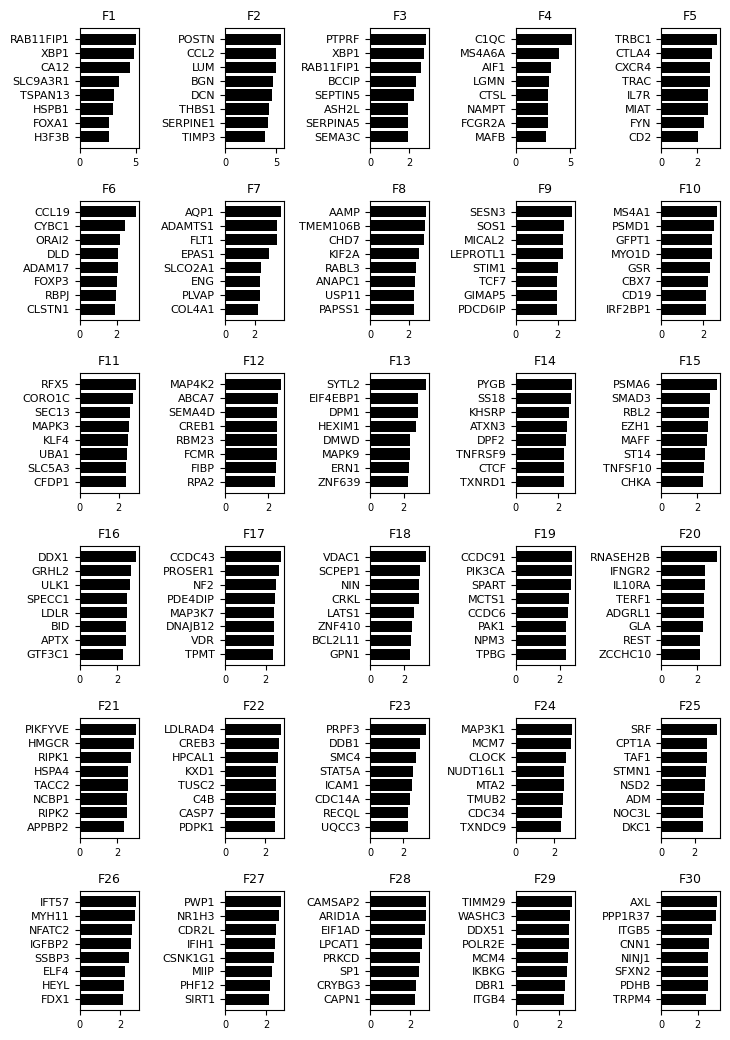

In [5]:
fit.plot_loadings(n_genes=8, ncol=5);


The stability plot summarizes multiseed NMF behavior. Points farther right are more abundant factors; higher points are more reproducible across random starts.


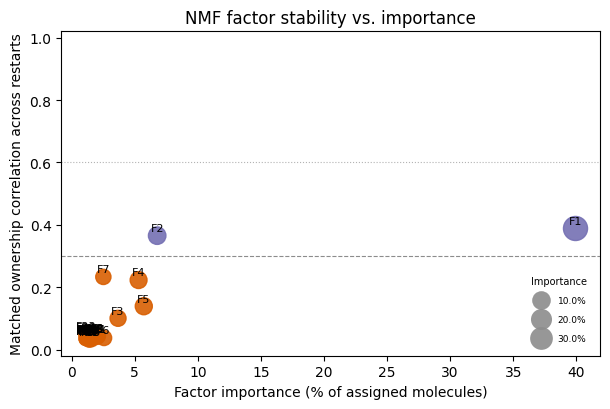

In [6]:
fit.plot_stability();


## Spatial Overview

For visual orientation, merge cell-level factor summaries with the provisional cluster labels. To keep the legend readable, clusters outside the largest 12 are grouped as `other` for this overview plot only.


In [7]:
cell_factors = fit.cell_factors()
cell_spatial = cell_factors.merge(annotation_table, on="cell_id", how="left")
top_clusters = annotation_table["cluster"].value_counts().head(12).index
cell_spatial["cluster_plot"] = cell_spatial["cluster"].where(cell_spatial["cluster"].isin(top_clusters), "other")
cell_spatial[["cell_id", "x", "y", "cluster", "dominant_factor", "transcript_count"]].head()


,cell_id,x,y,cluster,dominant_factor,transcript_count
0,imjonmkj-1,253.020111,12982.476562,cluster_1,2,13
1,imkckdbh-1,252.313660,12930.589844,cluster_2,28,20
2,imjoonig-1,241.917770,12923.190430,NaN,20,1
3,nlilhlfd-1,303.982422,3982.683105,NaN,15,2
4,nlmacoef-1,497.324615,5223.106445,cluster_3,2,40


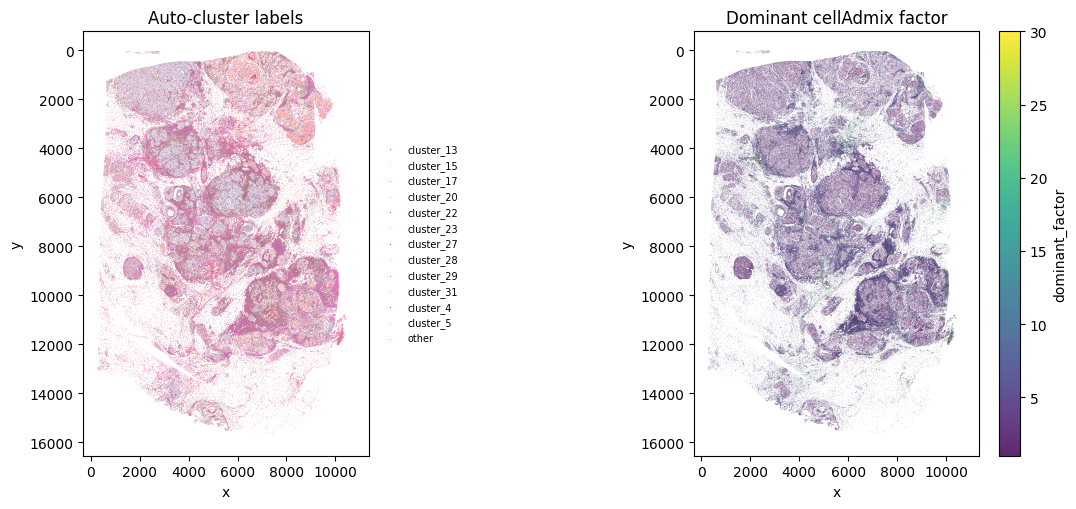

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
plot_spatial(cell_spatial, color_by="cluster_plot", title="Auto-cluster labels", ax=axes[0], s=0.03)
plot_spatial(cell_spatial, color_by="dominant_factor", title="Dominant cellAdmix factor", ax=axes[1], s=0.03)
plt.show()


## Admixture Audit

Before correcting anything, the audit estimates each ordered cluster
pair's admixture rate — the percent of the target cluster's molecules
that leaked in from the source — using only the spatial exposure
structure of the data. The same audit object verifies the correction
after cleanup.

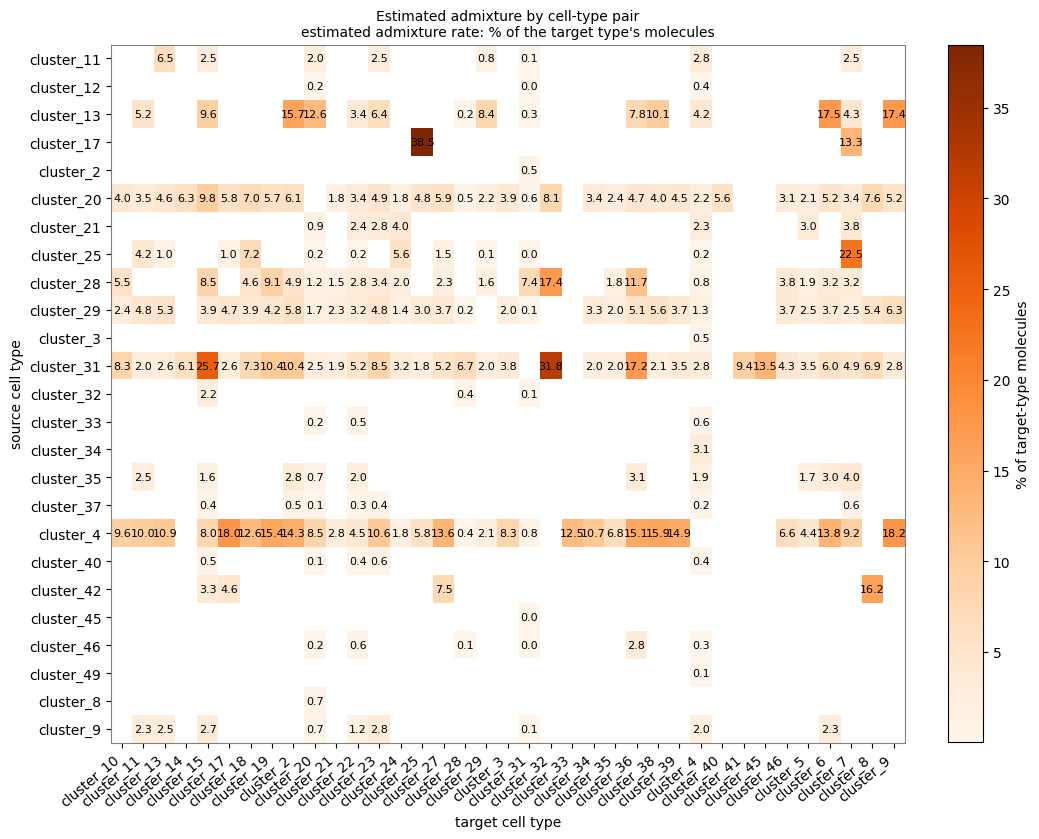

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 8.5))
audit = fit.audit_admixture()
audit.plot_map(ax=ax)
fig.tight_layout()

## Membrane Scoring

Membrane scoring asks whether target-cell molecules assigned to each factor are enriched along membrane-stain paths facing candidate source cells. This is the most expensive stage for this large dataset.


In [10]:
p_thresh = 0.1
membrane_score = fit.score_membrane(verbose=True)
membrane_score


[INFO 19:37:38 +61.742s] Starting membrane test: molecules=82144903, cells=688099 (0.000s)
[INFO 19:37:38 +61.743s] Opened membrane image: width=51265, height=74945 (0.000s)


[INFO 19:37:40 +63.503s] Prepared membrane data: cell_types=49, factors=30, active_cells=688099, typed_active_cells=629094 (1.760s)


[INFO 19:37:45 +68.571s] Discovered membrane candidates: pairs=897042 (5.068s)


[INFO 19:39:49 +193.118s] Scored membrane candidates: score_rows=2657150 (124.547s)


[INFO 19:39:50 +193.712s] Summarized membrane scores: summaries=59699 (0.593s)
[INFO 19:39:50 +193.712s] Finished membrane test: summaries=59699 (131.969s)


CellAdmixScore(method='membrane', n_summary=59699)

The heatmap summarizes source (`S`) and target correction (`*`) calls by factor and cluster label.


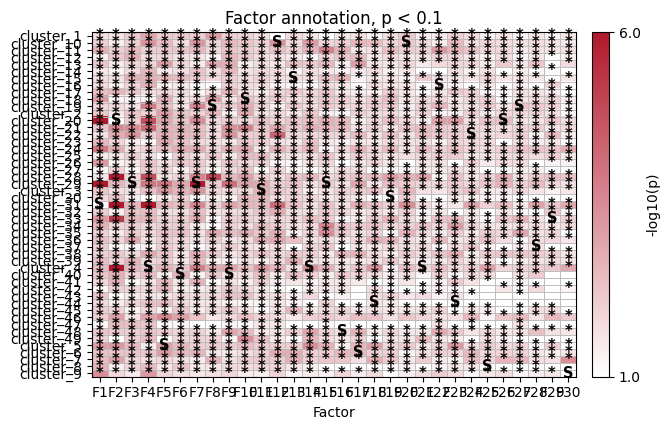

In [11]:
membrane_score.plot_heatmap(p_thresh=p_thresh, max_neg_log10=6);


The pair plots are shown for the most abundant factors rather than all 30 factors. Columns are candidate source clusters, rows are candidate target clusters, the top row shows source evidence, and the main matrix shows signed admixture significance.


In [12]:
factor_cols = [col for col in cell_factors.columns if col.startswith("factor_") and col.endswith("_fraction")]
importance = (cell_factors[factor_cols].to_numpy(float) * cell_factors["transcript_count"].to_numpy(float)[:, None]).sum(axis=0)
top_factors = [int(factor_cols[i].split("_")[1]) for i in importance.argsort()[::-1][:6]]
top_factors


[1, 2, 5, 4, 3, 6]

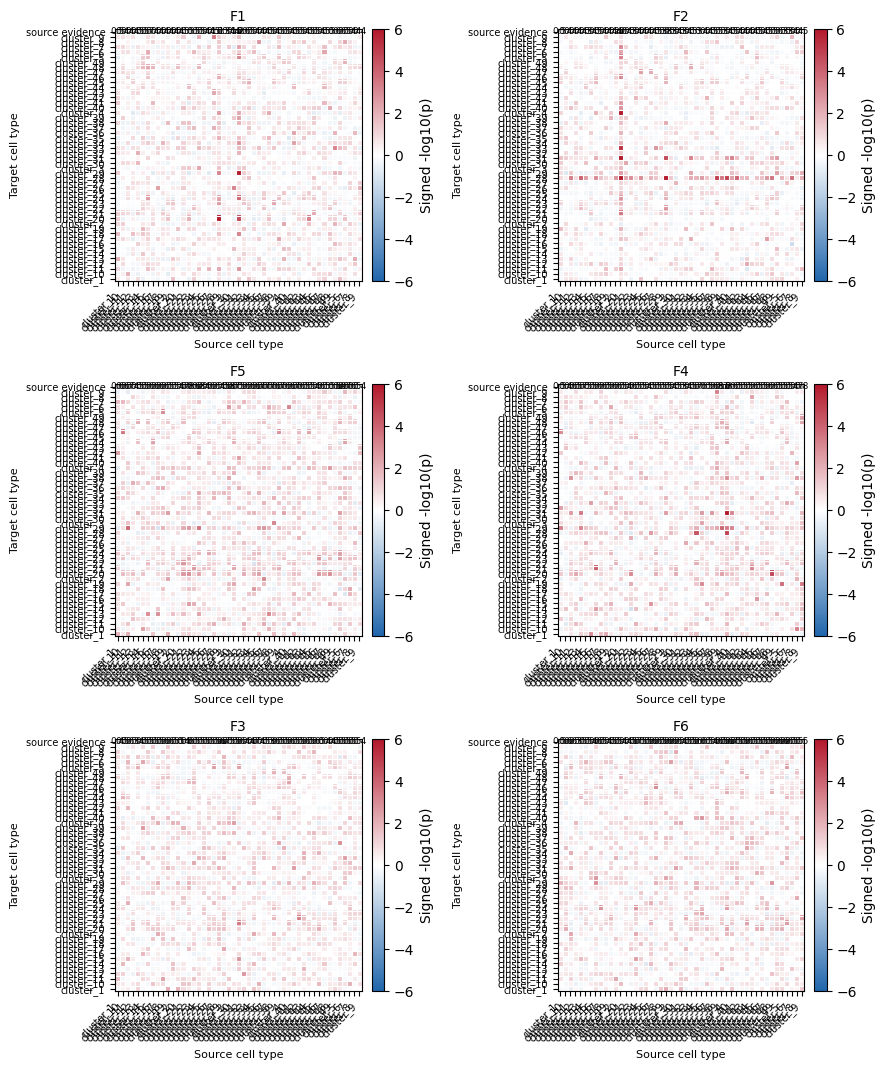

In [13]:
membrane_score.plot_pairs(factors=top_factors, p_thresh=p_thresh, max_abs_significance=6, ncol=2);


Correction rules are derived from factor annotations. Each rule removes molecules assigned to a factor from one target cluster; the source cluster is kept as the likely origin interpretation.


In [14]:
rules = membrane_score.rules(p_thresh=p_thresh)
rules[["factor", "source_cell_type", "target_cell_type", "p_value"]].head(20)


,factor,source_cell_type,target_cell_type,p_value
71,2,cluster_20,cluster_31,2.151630e-11
67,2,cluster_20,cluster_28,1.626813e-10
168,4,cluster_4,cluster_31,1.065923e-08
12,1,cluster_31,cluster_20,2.155259e-08
21,1,cluster_31,cluster_29,3.932730e-08
80,2,cluster_20,cluster_4,3.292009e-07
73,2,cluster_20,cluster_33,5.017188e-06
353,8,cluster_19,cluster_28,1.176710e-05
164,4,cluster_4,cluster_28,1.399385e-05
156,4,cluster_4,cluster_20,1.659409e-05


## Example Cells

The example-cell overlays show local molecule context before cleanup. Blue molecules are native factors for the target cluster, red molecules are the selected top admixture factor, and orange molecules are other non-native factors. Outside-cell molecules use the same colors at lower emphasis.


In [15]:
score_annotation = membrane_score.annotation(p_thresh=p_thresh)
diagnostic_cell_types = rules["target_cell_type"].value_counts().head(2).index.tolist()
diagnostic_cell_types


['cluster_28', 'cluster_35']

In [16]:
example_cells = membrane_score.examples(rules=rules, score_annotation=score_annotation,
    cell_data=cell_spatial, targets=diagnostic_cell_types, n_per_target=2)
example_cells[["target_cell", "target_cell_type", "top_admix_factor", "top_admix_source", "top_factor_molecules", "top_factor_fraction"]]


,target_cell,target_cell_type,top_admix_factor,top_admix_source,top_factor_molecules,top_factor_fraction
0,lhgnncfa-1,cluster_28,2,cluster_20,176.0,0.150556
1,eidjaofj-1,cluster_28,2,cluster_20,89.0,0.092805
2,cndcbono-1,cluster_35,1,cluster_31,18.0,0.187500
3,bpbpbeml-1,cluster_35,4,cluster_4,33.0,0.240876


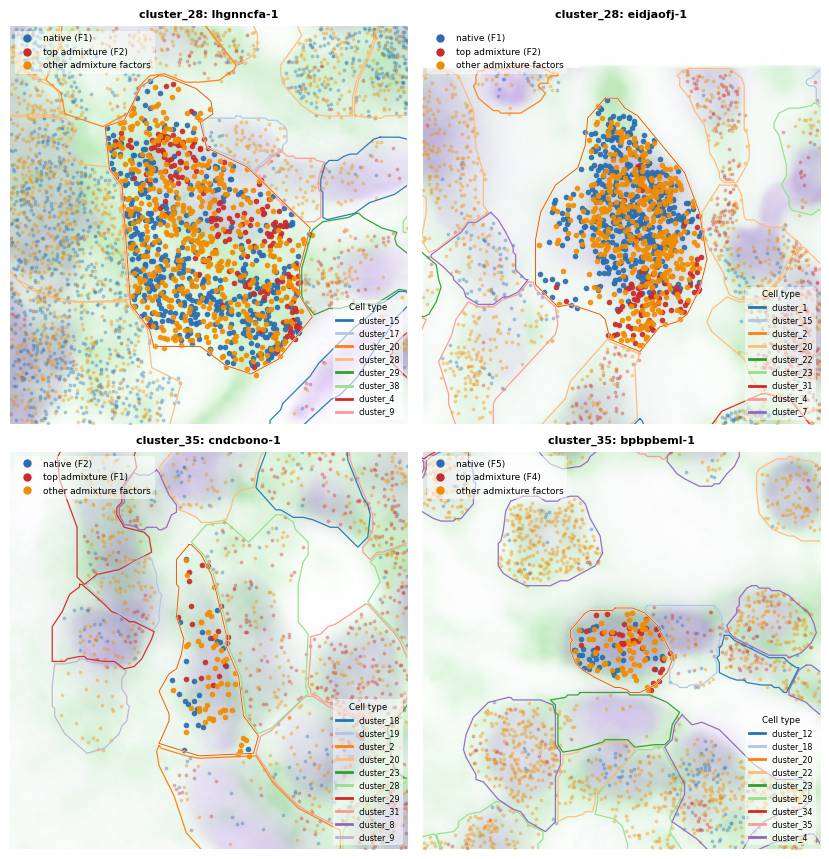

In [17]:

membrane_score.plot_examples(example_cells, score_annotation=score_annotation,
    cell_data=cell_spatial, ncol=2);


## Correction

The correction step applies all membrane-derived rules across annotated clusters and writes a corrected run. Because these are provisional clusters, the correction magnitude should be interpreted cautiously.


In [18]:
correction = membrane_score.correct(rules=rules, name="membrane_clean_notebook")
correction.summary().head(12)


Ensemble correction over 10 members: molecules removed by >= 3 members (vote >= 0.30) are dropped (29,020,633 molecules).


,cell_type,n_cells,n_modified_cells,fraction_cells_modified,molecules_before,molecules_after,molecules_removed,fraction_molecules_removed,median_removed_per_modified_cell,median_fraction_removed_per_modified_cell
0,all,688099,626319,0.910216,82144903.0,53124270.0,29020633.0,0.353286,36.0,0.558282
1,cluster_1,1275,1273,0.998431,35199.0,5917.0,29282.0,0.831899,19.0,0.857143
2,cluster_10,5486,5486,1.000000,234367.0,36829.0,197538.0,0.842858,32.0,0.856406
3,cluster_11,14144,14077,0.995263,816237.0,293513.0,522724.0,0.640407,34.0,0.666667
4,cluster_12,3218,3057,0.949969,74948.0,36043.0,38905.0,0.519093,8.0,0.476190
5,cluster_13,14633,14522,0.992414,581704.0,162916.0,418788.0,0.719933,22.0,0.750000
6,cluster_14,4019,4000,0.995272,100799.0,29032.0,71767.0,0.711981,14.0,0.764706
7,cluster_15,25131,25131,1.000000,902174.0,56888.0,845286.0,0.936943,27.0,0.950000
8,cluster_16,1996,1990,0.996994,38129.0,10476.0,27653.0,0.725248,11.0,0.777778
9,cluster_17,20253,19575,0.966523,386855.0,129097.0,257758.0,0.666291,8.0,0.666667


The audit verifies the cleanup against the same exposure measurements: the
report gives per-pair sensitivity and the own-marker false-removal rate,
and the panels show the estimated admixture remaining and the pooled
exposure profile before and after cleanup.


In [19]:
report = audit.evaluate(correction)
report.summary()

/tmp/ipykernel_2451233/346086481.py:1: UserWarning: Detected ~130,340 admixed molecules from cluster_11 into cluster_20, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_2451233/346086481.py:1: UserWarning: Detected ~214,072 admixed molecules from cluster_11 into cluster_4, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_2451233/346086481.py:1: UserWarning: Detected ~34,215 admixed molecules from cluster_12 into cluster_4, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_2451233/346086481.py:1: UserWarning: Detected ~824,689 admixed molecules from cluster_13 into cluster_20, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_2451233/346086481.py:1: UserWarning: Detected ~322,291 admixed molecules from cluster_13 into cluster_29, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_2451233/

{'detected_pairs': 248,
 'estimated_admixed_molecules': 15184473,
 'leakage_removed_overall': np.float64(0.5657871296159956),
 'median_pair_sensitivity': 0.9802634242878752,
 'own_marker_false_removal': 0.05167732143330266}

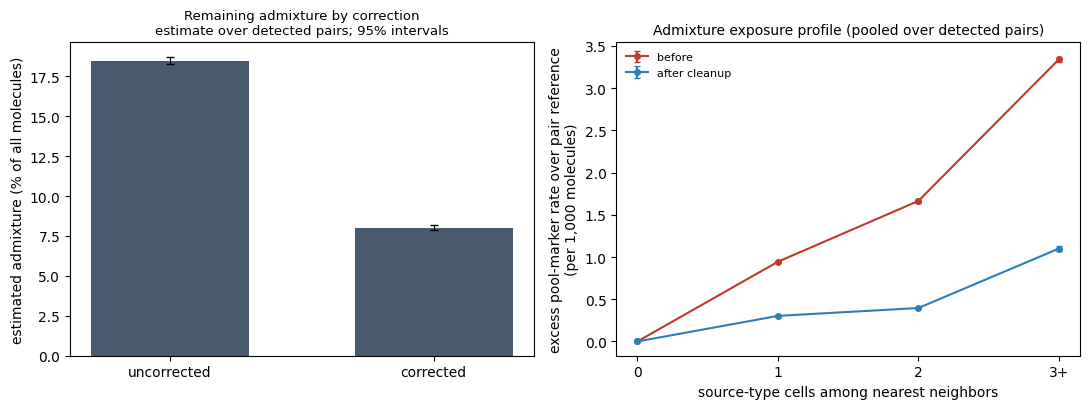

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
audit.plot_remaining({"corrected": correction}, ax=axes[0])
audit.plot_exposure(correction=correction, ax=axes[1])
fig.tight_layout()

The molecule-removal plot is restricted to the most affected clusters plus the aggregate row, which keeps the large-cluster result readable.


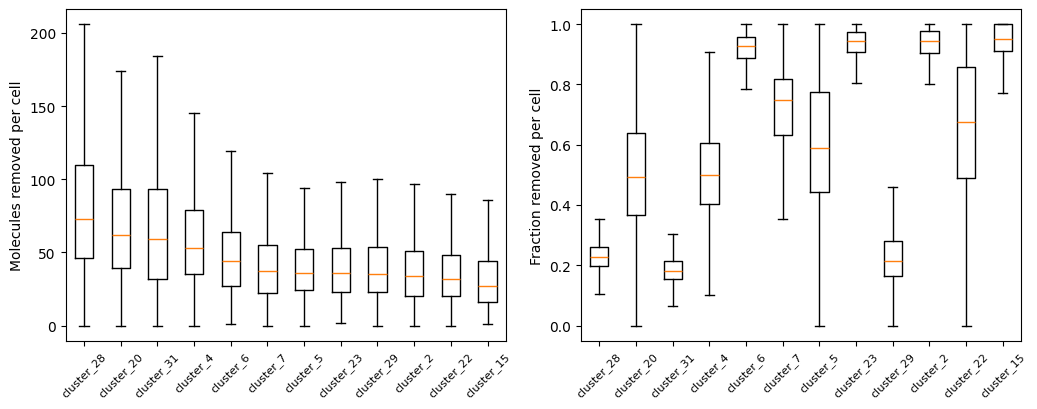

In [21]:
cell_summary = correction.cell_summary()
top_removed = (cell_summary.groupby("cell_type")["n_removed"].sum()
    .sort_values(ascending=False).head(12).index.tolist())
plot_summary = cell_summary[cell_summary["cell_type"].isin(top_removed)]
plot_molecule_removal(plot_summary);


A compact cell-state diagnostic compares original and corrected cell-level expression neighborhoods on a 5,000-cell subset. The score is same-label kNN purity in PCA space, normalized against the label-frequency baseline.


In [22]:
state_cells_max = 5000
original_state = ds.cell_state_umap(cells_max=state_cells_max, num_threads=num_threads)
corrected_state = correction.cell_state_umap(annotation=annotation,
    cells_max=state_cells_max, num_threads=num_threads)

state_scores = pd.DataFrame([
    annotation_knn_purity(original_state),
    annotation_knn_purity(corrected_state),
], index=["original", "corrected"])
state_scores


,knn_same_type_fraction,baseline_fraction,normalized_purity
original,0.483267,0.069383,0.444741
corrected,0.605080,0.122127,0.550140


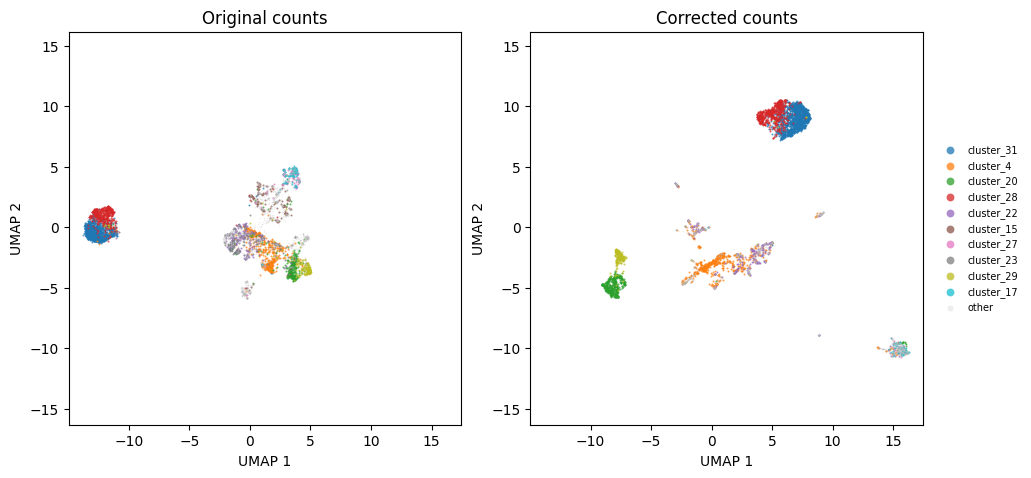

In [23]:
def state_umap_limits(*frames, pad_fraction=0.04):
    x = pd.concat([frame["umap_1"] for frame in frames]).to_numpy(dtype=float)
    y = pd.concat([frame["umap_2"] for frame in frames]).to_numpy(dtype=float)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    span = max(xmax - xmin, ymax - ymin)
    pad = span * pad_fraction
    xmid = (xmin + xmax) / 2
    ymid = (ymin + ymax) / 2
    half = span / 2 + pad
    return (xmid - half, xmid + half), (ymid - half, ymid + half)


def plot_state_umap(frame, title, ax, palette, xlim, ylim):
    labels_to_show = list(palette.keys())
    labels = frame["cell_type"].astype(str)
    for label, color in palette.items():
        mask = labels == label
        if mask.any():
            ax.scatter(frame.loc[mask, "umap_1"], frame.loc[mask, "umap_2"],
                s=2.0, alpha=0.75, linewidths=0, color=color, label=label, rasterized=True)
    other = ~labels.isin(labels_to_show)
    if other.any():
        ax.scatter(frame.loc[other, "umap_1"], frame.loc[other, "umap_2"],
            s=1.2, alpha=0.25, linewidths=0, color="#bdbdbd", label="other", rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")


state_labels = annotation.value_counts().head(10).index.tolist()
colors = plt.get_cmap("tab10")
palette = {label: colors(i) for i, label in enumerate(state_labels)}
xlim, ylim = state_umap_limits(original_state, corrected_state)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.8), constrained_layout=True)
plot_state_umap(original_state, "Original counts", axes[0], palette, xlim, ylim)
plot_state_umap(corrected_state, "Corrected counts", axes[1], palette, xlim, ylim)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, markerscale=4, fontsize=7)
plt.show()
